In [28]:
import flopy
import numpy as np
import matplotlib.pyplot as plt
import os
import xmf6 # biblioteca con algunas herramientas adicionales

# --- Ruta a los ejecutables de MODFLOW 6. Opciones de SO's: linux, macos, macosarm, windows
mf6_exe = "C:\\Users\\luiggi\\Documents\\GitSites\\xmf6\\mf6\\windows\\mf6"

# --- Configuración inicial ---
model_name = "flow"
sim_ws = "sandbox3"

sim = flopy.mf6.MFSimulation(
    sim_name = model_name,
    exe_name = mf6_exe,
    sim_ws   = sim_ws
)

# --- Tiempos de simulación ---
o_tdis = flopy.mf6.ModflowTdis(
    simulation = sim,
    time_units = "DAYS",
    nper = 1,
    perioddata = [(1.0, 1, 1.0)],
)

# --- Solucionador numérico (IMS) ---
o_ims = flopy.mf6.ModflowIms(
    simulation          = sim,
    print_option        = "SUMMARY",
    complexity          = "SIMPLE",
    outer_dvclose       = 1e-4,
    outer_maximum       = 50,
    under_relaxation    = "NONE",
    linear_acceleration = "CG",
    inner_maximum       = 30,
    inner_dvclose       = 1e-6,
)

# --- Modelo GWF ---
o_gwf = flopy.mf6.ModflowGwf(
    simulation = sim,
    modelname = model_name,
    model_nam_file = f"{model_name}.nam",
    save_flows = True # Almacena los flujos, particularmente el budget
)

#### PAQUETES

# --- Malla del modelo ---
nlay = 1
nrow = 100
ncol = 150
delr = 1.0
delc = 1.0
top  = 0.0
botm = -1.0

o_dis = flopy.mf6.ModflowGwfdis(
    model = o_gwf,
    length_units = "METERS",
    nlay = nlay,
    nrow = nrow,
    ncol = ncol,
    delr = delr,
    delc = delc,
    top  = top,
    botm = botm,
)

o_ic = flopy.mf6.ModflowGwfic(
    model = o_gwf,
    strt=10.0 
)

chd_data = []
for row in range(nrow):
    chd_data.append([(0, row, 0), 10.0])       # Condición en la pared izquierda
    chd_data.append([(0, row, ncol - 1), 5.0]) # Condición en la pared derecha

o_chd = flopy.mf6.ModflowGwfchd(
    model = o_gwf,
    stress_period_data=chd_data,
)


# Creamos un arreglo de conductividad hidráulica para toda la grilla
#k_array = np.ones((nlay, nrow, ncol))  # Inicializamos con 1.0
k_array = np.random.rand(nlay, nrow, ncol)*0.01  # Inicializamos con 1.0

# Asignamos una conductividad baja en la mitad derecha del dominio
k_array[:, 20:120, 20:120] = 0.01  # columnas 5 a 9

o_npf = flopy.mf6.ModflowGwfnpf(
    model = o_gwf,
    save_specific_discharge = True,
    k = k_array, # conductividad hidráulica
)

o_oc = flopy.mf6.ModflowGwfoc(
    model = o_gwf,
    budget_filerecord = f"{model_name}.bud",
    head_filerecord = f"{model_name}.hds",
    saverecord = [("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord = [("HEAD", "ALL")]
)


# --- Escribimos los archivos ---
sim.write_simulation()


sim.run_simulation(silent=False)



writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model flow...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package chd_0...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 200 based on size of stress_period_data
    writing package npf...
    writing package oc...
FloPy is using the following executable to run the model: ..\..\..\..\mf6\windows\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

   MODFLOW 6 compiled Feb 10 2025 17:37:25 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been 

(True, [])

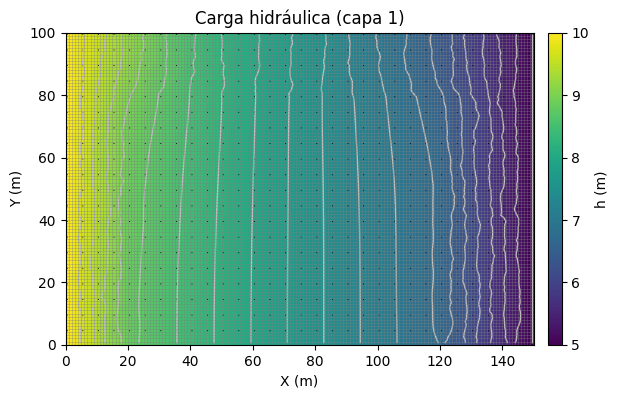

In [29]:
# construimos el nombre con la ruta y extensión correcta
headfile = os.path.join(f"{sim_ws}", f"{model_name}.hds")

# Objeto para obtener y manipular arreglos o series de tiempo de arreglos con datos
# de una o más celdas con información del archivo binario de la carga hidráulica.
hds = flopy.utils.HeadFile(headfile)

# Solo se obtiene la capa 0, cuando no se pone ningún valor en el parámetro mlay se obtienen todas las capas
head = hds.get_data(mflay=0)

# construimos el nombre con la ruta y extensión correcta
budfile = os.path.join(f"{sim_ws}", f"{model_name}.bud")

# Objeto para obtener y manipular arreglos o series de tiempo de arreglos con datos
# de una o más celdas con información del archivo binario del budget.
bud  = flopy.utils.CellBudgetFile(budfile)

# Cargar resultados de la descarga específica
spdis = bud.get_data(text="DATA-SPDIS")[0]

# Extraer componentes del flujo en un arreglo 3D para graficación
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, o_gwf)

# Coordenadas del centro de celdas para graficación
x, y, z = o_gwf.modelgrid.xyzcellcenters

fig = plt.figure()
ax = fig.gca() # Ejes donde se hará la graficación

# Mapa visual del modelo. En este caso el modelo es 'o_gwf'.
mapview = flopy.plot.PlotMapView(model=o_gwf, ax=ax)

# Visualización de la carga hidráulica usando un mapa de color.
cb = mapview.plot_array(head, cmap="viridis", vmin=np.nanmin(head), vmax=np.nanmax(head))

# Visualización de la carga hidráulica usando contornos.
ct = mapview.contour_array(head, levels=20, linewidths=1.0, colors='silver')

# Graficar los vectores de flujo
skip = (slice(None, None, 5), slice(None, None, 5))  # Saltar para no saturar
ax.quiver(x[skip], y[skip], qx[0][skip], qy[0][skip], scale=0.25, color='k', pivot='middle')
#ax.streamplot(x, y, qx[0], qy[0], density=0.6, color='k', linewidth=0.5)

# Visualización de la malla, con una transparencia.
mapview.plot_grid(linewidths=0.5, alpha =0.5)


# Barra de color.
plt.colorbar(cb, ax=ax, label="h (m)", cax = xmf6.vis.cax(ax, cb))

# Personalización de la gráfica.
ax.set_title("Carga hidráulica (capa 1)")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_aspect('equal')
plt.show()


